In [1]:
import sys
import os

path_racine = os.path.abspath('..')

if path_racine not in sys.path:
    sys.path.append(path_racine)

from src.model import (
    DHP,
    CHP, CHP_plot, CHP_IC_plot,
    neg_log_likelihood, hawkes_residuals, engle_russell_ed_test,
    neg_log_likelihood_bivariate, spectral_det, trace_1, trace_2,
    hawkes_residuals_bivariate,
    neg_log_likelihood_bivariate_sum_exp, hawkes_residuals_bivariate_sum_exp,
)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize, NonlinearConstraint, LinearConstraint
from scipy.stats import kstest
from statsmodels.stats.diagnostic import acorr_ljungbox
from tick.hawkes import SimuHawkesExpKernels, SimuHawkesSumExpKernels

In [3]:
%matplotlib inline

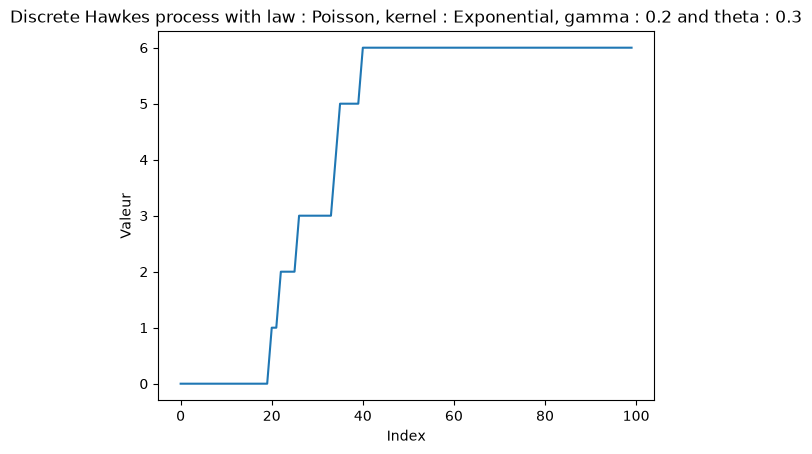

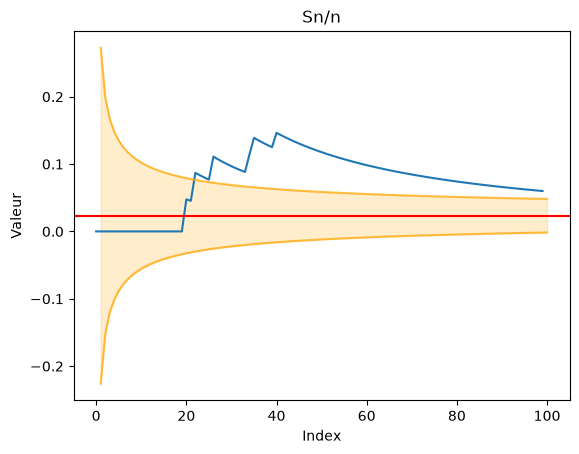

In [4]:
#Plot of a Discrete Hawkes Process

DHP("Exponential", 0.2, 0.3, "Poisson", 100, 0.01)

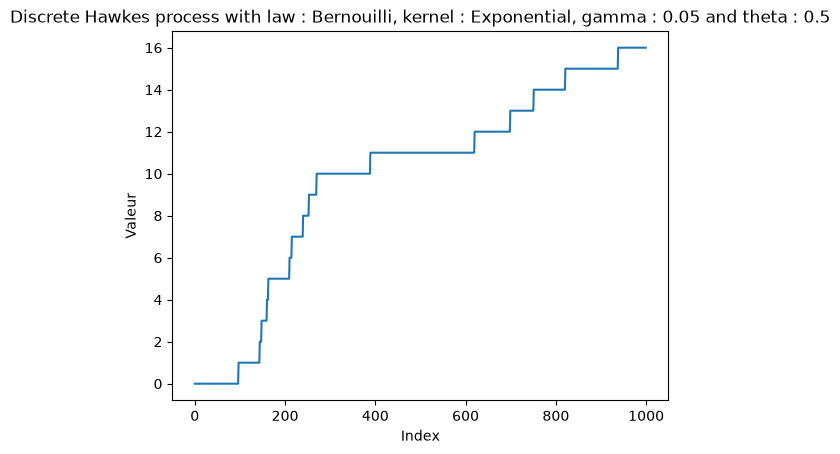

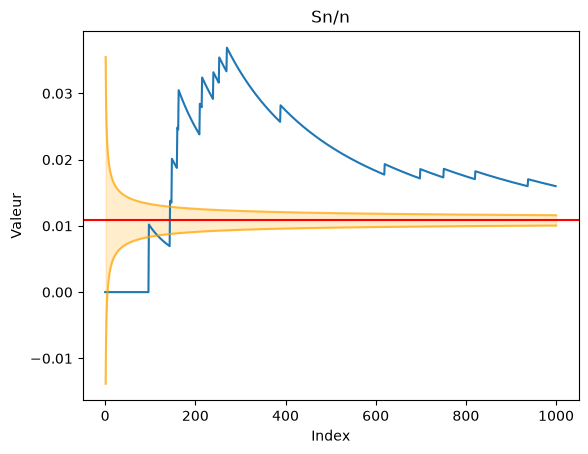

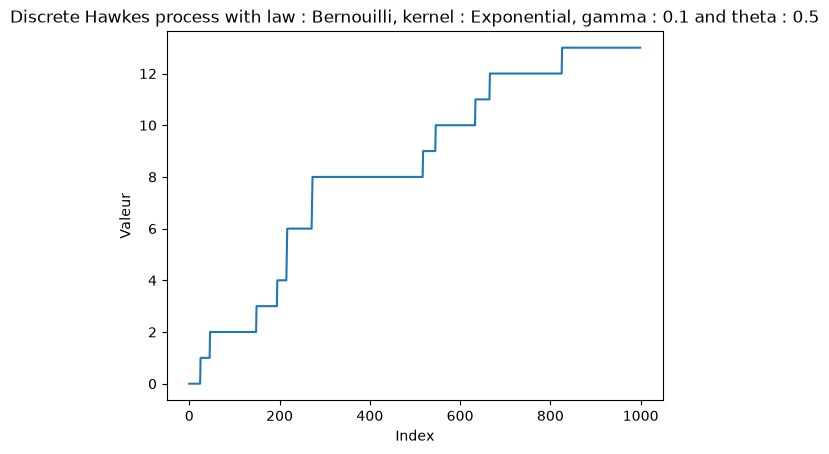

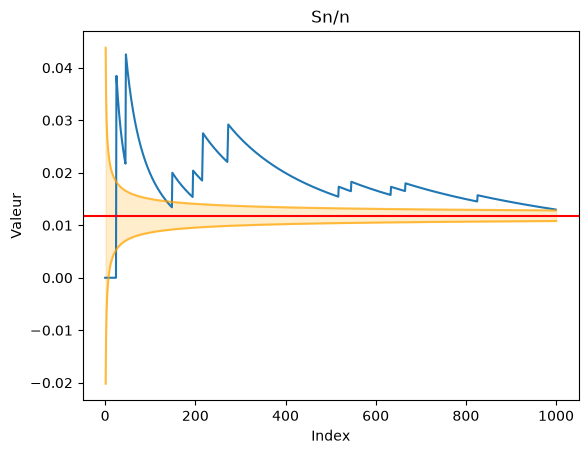

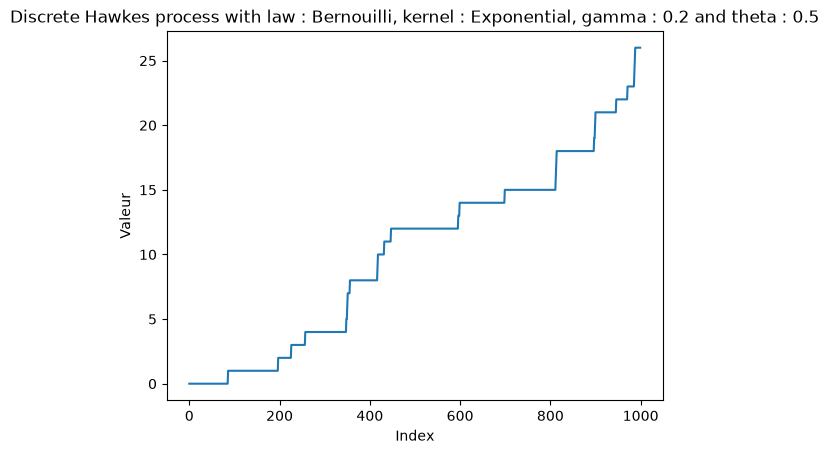

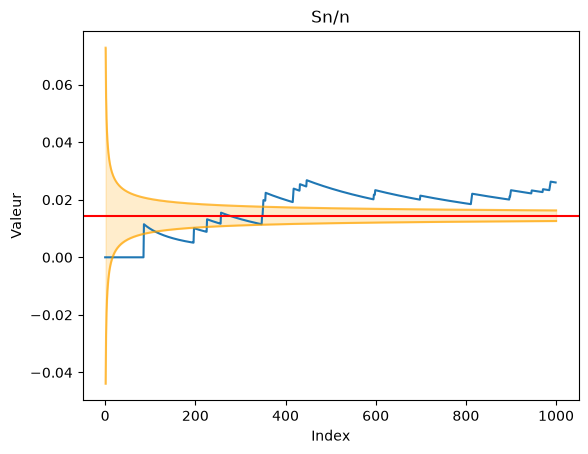

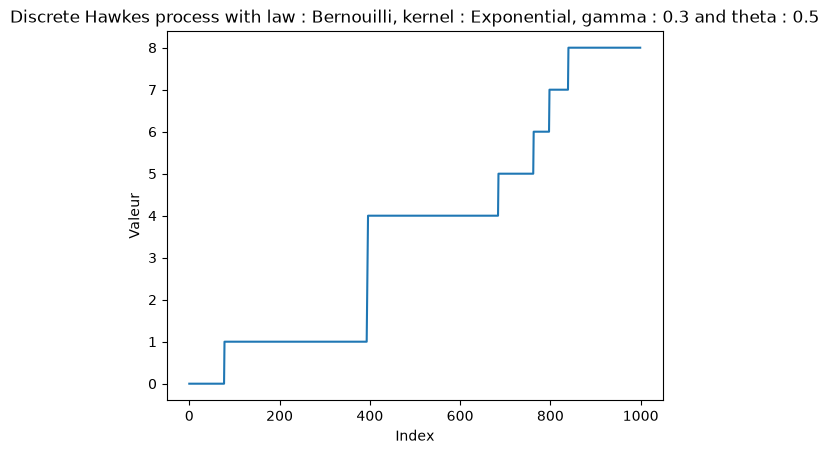

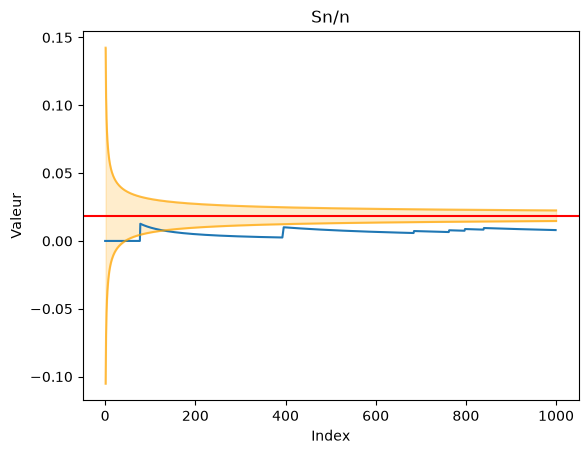

In [5]:
DHP("Exponential", 0.05, 0.5, "Bernouilli", 1000, 0.01)
DHP("Exponential", 0.10, 0.5, "Bernouilli", 1000, 0.01)
DHP("Exponential", 0.20, 0.5, "Bernouilli", 1000, 0.01)
DHP("Exponential", 0.30, 0.5, "Bernouilli", 1000, 0.01)


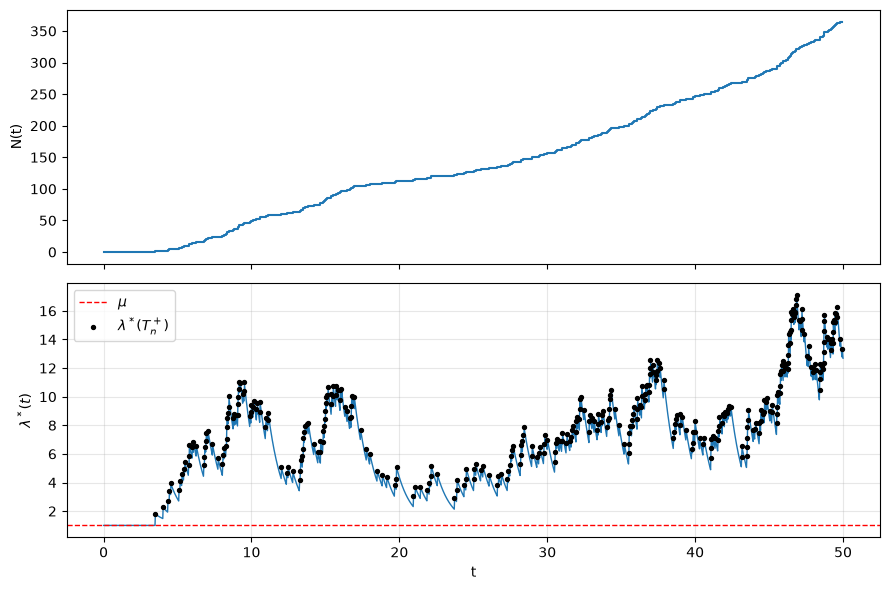

In [6]:
mu = 1.0    # baseline
gamma  = 0.8    # amplitude
beta   = 1.0    # decay
T_max  = 50.0

#Plot of N(t) for a Continuous Hawkes Process

CHP_plot(mu,beta,gamma,T_max)

Baseline / weakly self-exciting


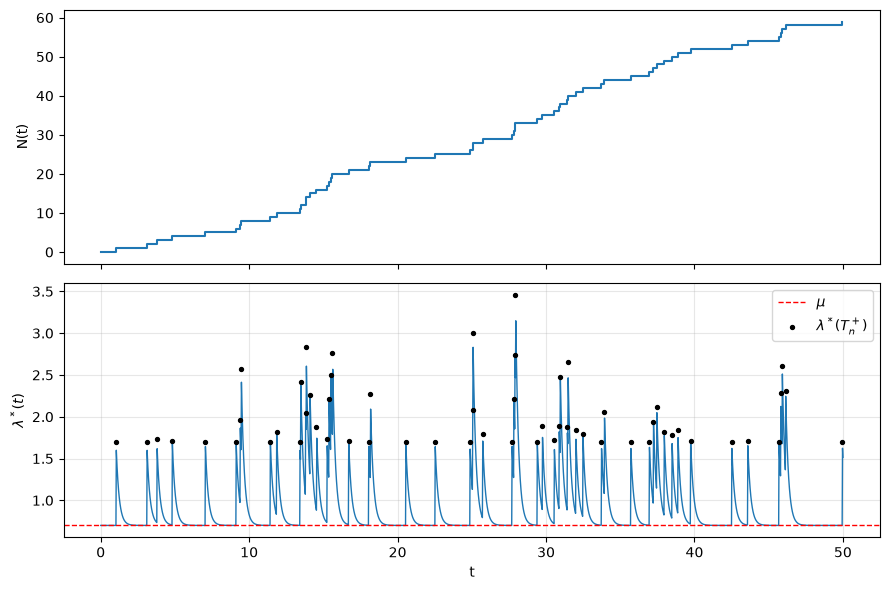

Branching ratio > 1 : we violate the condition of stationnarity


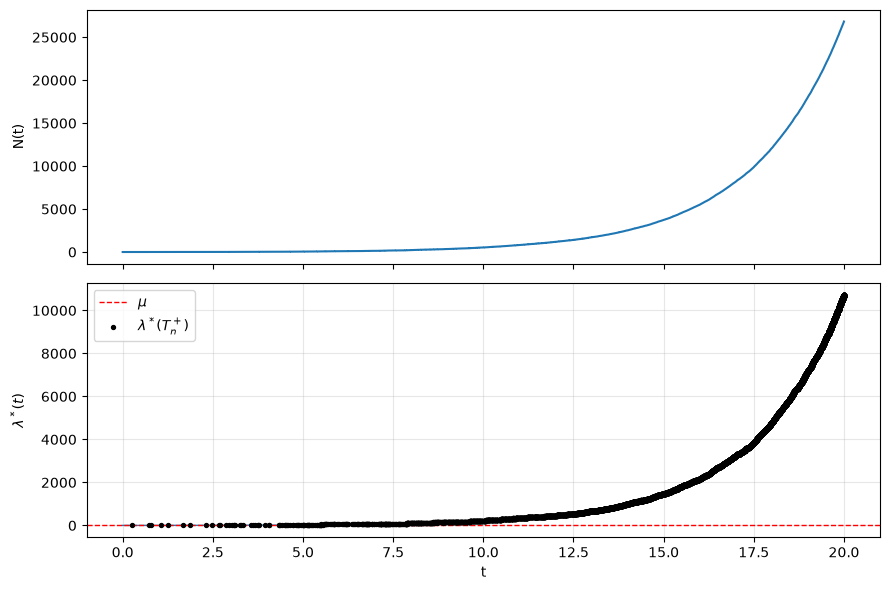

Near-critical: heavy cascades (reduced T_max to prevent event explosion)


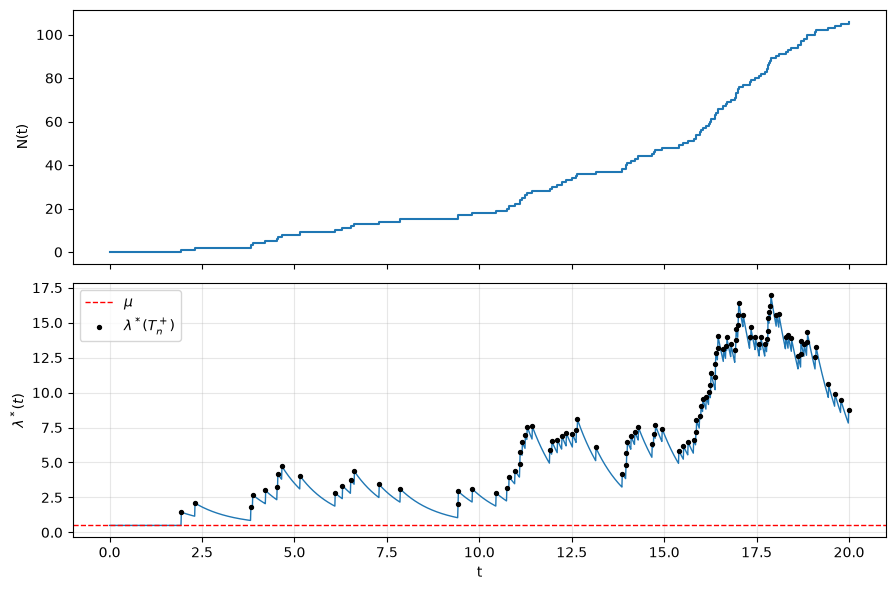

Short memory: tight bursts followed by fast decay back to baseline


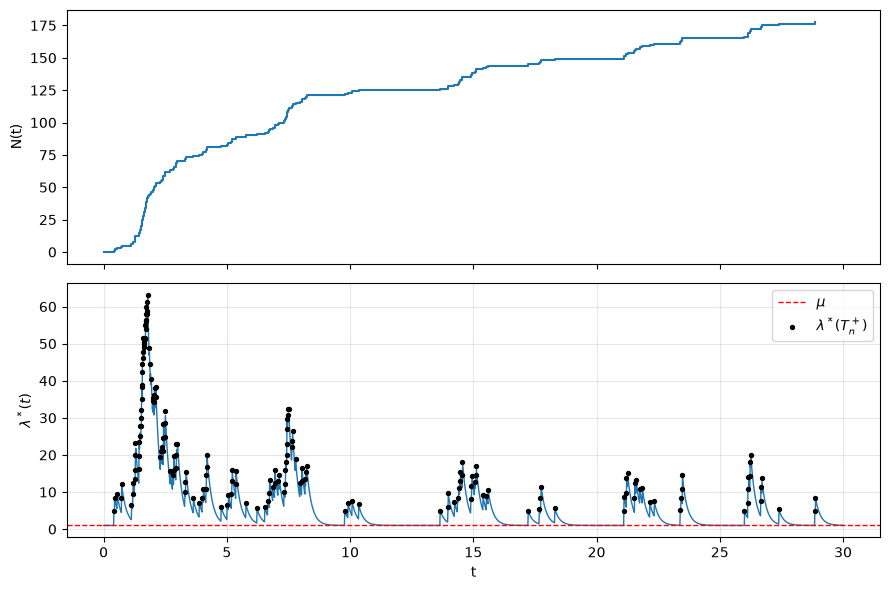

Long memory: persistent excitation, spread-out clusters


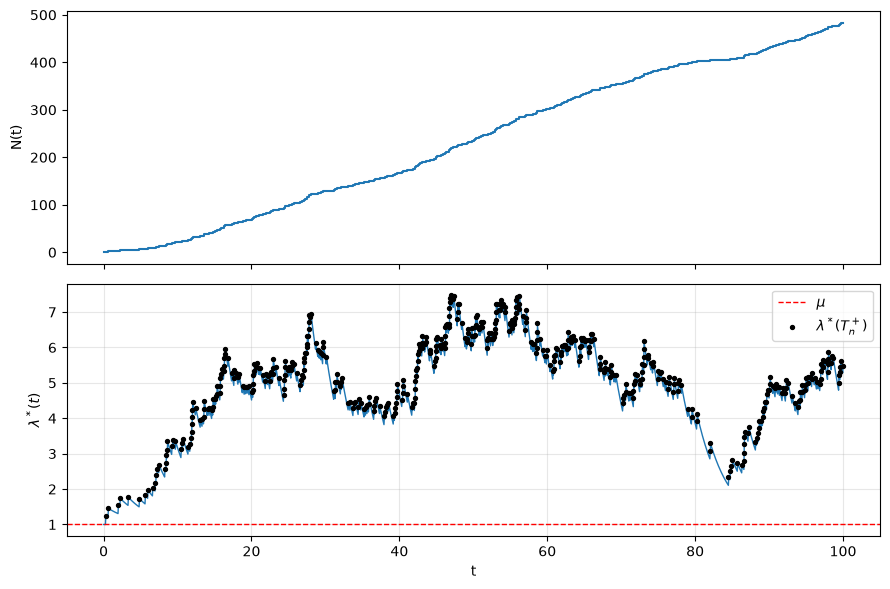

Low baseline, strongly self-exciting: long silent periods followed by bursts


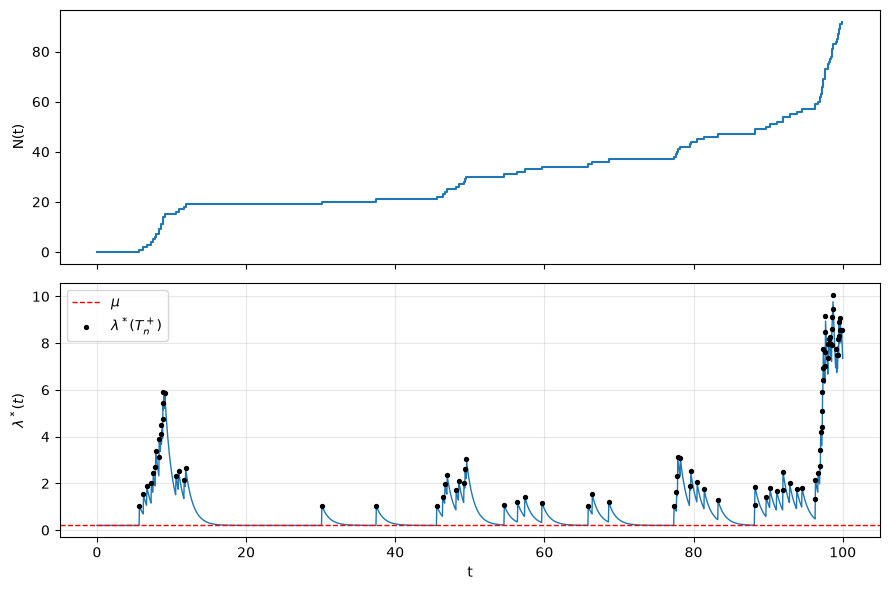

In [7]:
# mu    (baseline)    : lower bound of lambda* and rate of spontaneous events.
#                       higher -> fewer silent periods, steeper baseline slope of N(t).
# gamma (amplitude)   : jump size of lambda* upon each event.
#                       higher -> stronger clustering; approaching 0 -> homogeneous Poisson.
# beta  (decay)       : mean reversion speed toward mu; memory ~ 1/beta.
#                       large -> compact bursts; small -> spread-out clusters.
# gamma/beta (branching ratio): global regime. approaching 0 -> near-Poisson;
#                               approaching 1 -> heavy cascades; >= 1 -> explosive/non-stationary.
#                               average intensity = mu / (1 - gamma/beta).


# Be aware, in the small note : we use alpha rather than gamma, thus, the print/title of some figures will include alpha rather than gamma


#  Baseline / weakly self-exciting*
print("="*40)  
print("Baseline / weakly self-exciting")  
print("="*40)  
CHP_plot(mu=0.7, beta=5, gamma=1, T_max=50)   

# branching ratio > 1 : we violate the condition of stationnarity
print("="*40)  
print("Branching ratio > 1 : we violate the condition of stationnarity")  
print("="*40)  
CHP_plot(mu=0.5, beta=1.0, gamma=1.4, T_max=20)

# Near-critical: heavy cascades (reduced T_max to prevent event explosion)
print("="*40)  
print("Near-critical: heavy cascades (reduced T_max to prevent event explosion)")
print("="*40)  
CHP_plot(mu=0.5, beta=1.0, gamma=0.95, T_max=20)

# Short memory: tight bursts followed by fast decay back to baseline
print("="*40)  
print("Short memory: tight bursts followed by fast decay back to baseline")
print("="*40)  
CHP_plot(mu=1.0, beta=5.0, gamma=4.0, T_max=30)

# Long memory: persistent excitation, spread-out clusters
print("="*40)  
print("Long memory: persistent excitation, spread-out clusters")
print("="*40)  
CHP_plot(mu=1.0, beta=0.3, gamma=0.24, T_max=100)

# Low baseline, strongly self-exciting: long silent periods followed by bursts
print("="*40)  
print("Low baseline, strongly self-exciting: long silent periods followed by bursts")
print("="*40)  
CHP_plot(mu=0.2, beta=1.0, gamma=0.85, T_max=100)


In [8]:
# We aim to derive two types of confidence intervals:
# 1. Confidence intervals that depend on v (the fraction of the observation window [0, T] observed).
# 2. A uniform confidence interval independent of v, which holds valid across any observed fraction of [0, T].

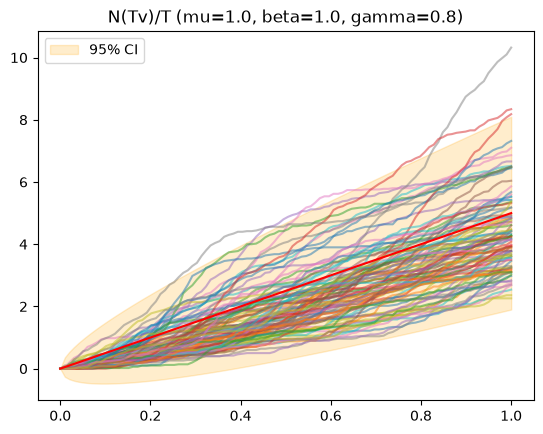

In [9]:
# Confidence intervals that depend on v !

CHP_IC_plot(mu,beta,gamma,T_max)

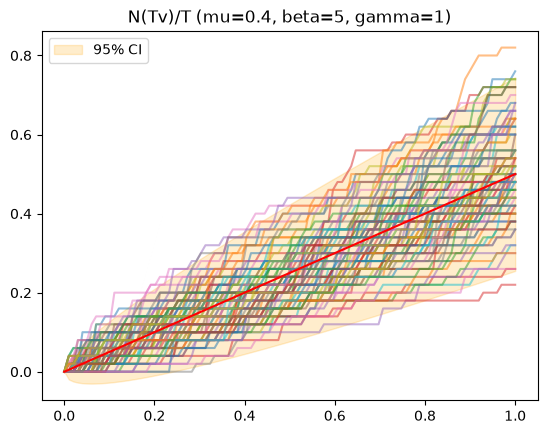

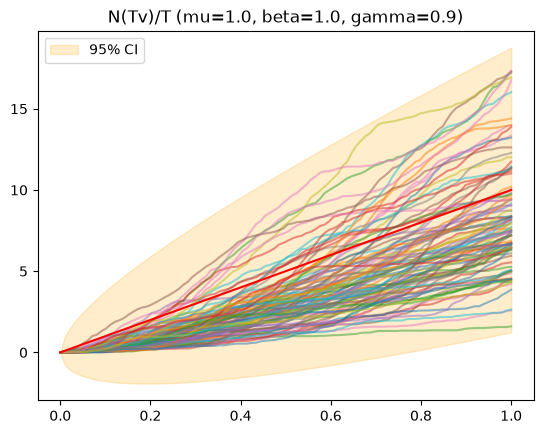

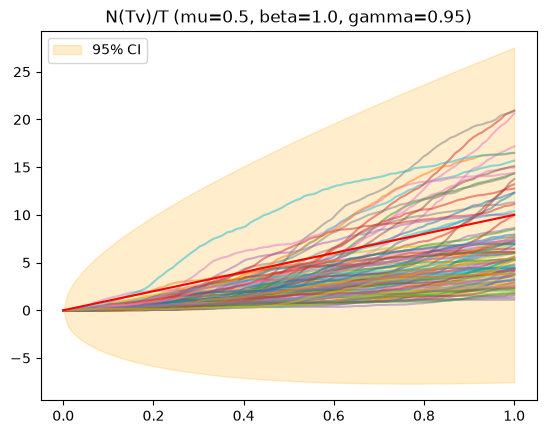

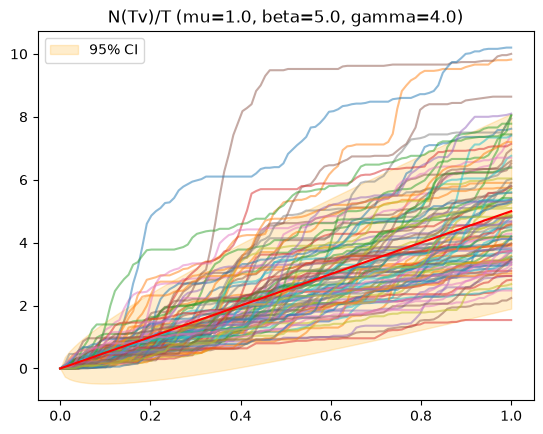

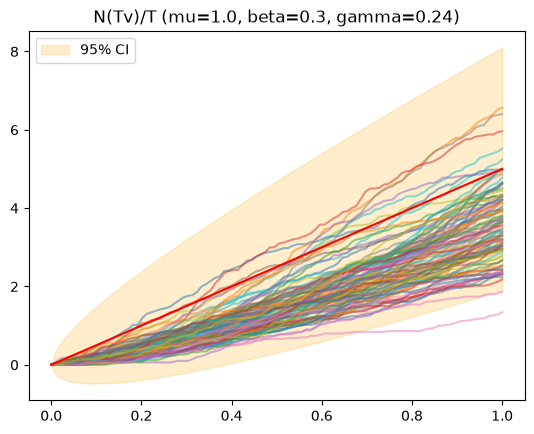

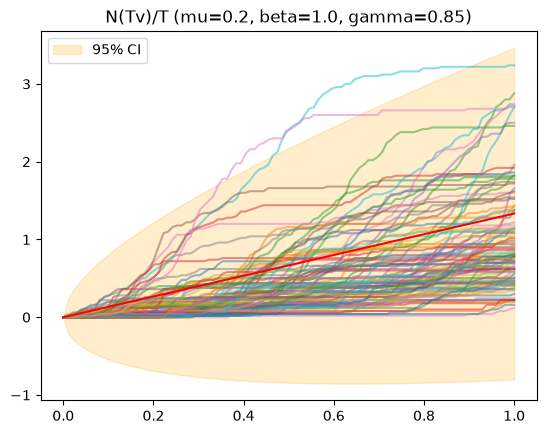

In [10]:
# Plots to evaluate the behavior of the confidence intervals

# 1. Baseline / weakly self-exciting
CHP_IC_plot(mu=0.4, beta=5, gamma=1, T_max=50)     

# 2. Strong yet stationary clustering
CHP_IC_plot(mu=1.0, beta=1.0, gamma=0.9, T_max=50)

# 3. Near-critical: heavy cascades (reduced T_max to prevent event explosion)
CHP_IC_plot(mu=0.5, beta=1.0, gamma=0.95, T_max=50)

# 4. Short memory: tight bursts followed by fast decay back to baseline
CHP_IC_plot(mu=1.0, beta=5.0, gamma=4.0, T_max=50)

# 5. Long memory: persistent excitation, spread-out clusters
CHP_IC_plot(mu=1.0, beta=0.3, gamma=0.24, T_max=50)

# 6. Low baseline, strongly self-exciting: long silent periods followed by bursts
CHP_IC_plot(mu=0.2, beta=1.0, gamma=0.85, T_max=50)

In [11]:
# We only keep time_stamps of our Continuous Hawkes Process

time_stamp=CHP(mu=1.0, beta=0.3, gamma=0.24, T_max=10000)

In [12]:
# Parameter Init and bounds

theta_init = np.array([0.5, 0.5, 0.3]) 


bounds = ((1e-5, None), (1e-5, 0.999), (1e-5, None))


# Optimization using Maximum Likelihood Estimator 

resultat = minimize(
    fun=neg_log_likelihood,
    x0=theta_init,
    args=(time_stamp,),
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 2000, 'ftol': 1e-9}
)

print("\n--- ESTIMATION RESULTS ---")
print(f"Estimated baseline intensity (mu) : {resultat.x[0]:.4f}")
print(f"Estimated branching ratio (R)     : {resultat.x[1]:.4f}")
print(f"Estimated beta (decay)            : {resultat.x[2]:.4f}")
print(f"-> Implied gamma (amplitude)      : {(resultat.x[1] * resultat.x[2]):.4f}")
print(f"Optimization success              : {resultat.success}")

/home/onyxia/work/Spread_Crypto/src/model.py:182: RuntimeWarning: overflow encountered in exp
  A[i] = (1 + A[i-1]) * np.exp(-beta * (time_stamp[i] - time_stamp[i-1]))


ValueError: setting an array element with a sequence.

In [ ]:
# First two tests of Goodness of fit (with respect to the simulator : so the results should be very accurate)


theta_estime = [1.0055, 0.7997, 0.2981] 

# residuals estimated
u = hawkes_residuals(theta_estime, time_stamp)

print("--- Goodness of fit ---")

# TEST 1 : Kolmogorov-Smirnov (Marginal distribution Exp(1))
# H0 : data follows an Exp(1) distribution
ks_stat, ks_pval = kstest(u, 'expon')
print(f"KS Test       -> Stat: {ks_stat:.4f} | p-value: {ks_pval:.4f}")

# TEST 2 : Ljung-Box (Linear AC until the 20th lag)
# H0 : residuals are independant (no autocorrelation)
lb_result = acorr_ljungbox(u, lags=[20], return_df=True)
lb_pval = lb_result['lb_pvalue'].iloc[0]
print(f"Ljung-Box     -> Stat: {lb_result['lb_stat'].iloc[0]:.4f} | p-value: {lb_pval:.4f}")

In [ ]:
# Third test of Goodness of fit (with respect to the simulator)

#Test of excess of dispersion
#H0 : the variance of residuals is 1
sigma2_empirique, ed_stat, ed_pval = engle_russell_ed_test(u)

print(f"empirical variance of résidus : {sigma2_empirique:.4f}")
print(f"Engle-Russell ED Test -> Stat Z: {ed_stat:.4f} | p-value: {ed_pval:.4f}")

In [ ]:
# Pass_rate for a univariate Hawkes (with respect to the simulator)

count_ks = 0
count_lb = 0
count_er = 0
count_joint = 0

# Let's try to implement the pass_rate idea of the article

numerous_timestamps = [CHP(mu=1.0, beta=0.3, gamma=0.24, T_max=10000) for _ in range(10)]

taille = len(numerous_timestamps)
theta_init = np.array([0.5, 0.5, 0.3]) 
bounds = ((1e-5, None), (1e-5, 0.999), (1e-5, None))

for k in range(taille):
    current_timestamps = numerous_timestamps[k]

    resultat = minimize(
        fun=neg_log_likelihood, 
        x0=theta_init,
        args=(current_timestamps,), 
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 2000, 'ftol': 1e-9}
    )

    theta_estimate = resultat.x
    
    u = hawkes_residuals(theta_estimate, current_timestamps)

    ks_stat, ks_pval = kstest(u, 'expon')

    lb_result = acorr_ljungbox(u, lags=[20], return_df=True)
    lb_pval = lb_result['lb_pvalue'].iloc[0]

    _, _, er_pval = engle_russell_ed_test(u)


    if ks_pval > 0.05:
        count_ks += 1

    if lb_pval > 0.05:
        count_lb += 1

    if er_pval > 0.05:
        count_er += 1

    if ks_pval > 0.05 and lb_pval > 0.05 and er_pval > 0.05:
        count_joint += 1

print("\n--- RÉSULTATS DES PASS RATES (sur 50 simulations) ---")
print(f"Pass Rate KS : {(count_ks / taille) * 100:.2f}%")
print(f"Pass Rate LB : {(count_lb / taille) * 100:.2f}%")
print(f"Pass Rate ED : {(count_er / taille) * 100:.2f}%")
print(f"Pass Rate Joint (KS ∩ LB ∩ ED) : {(count_joint / taille) * 100:.2f}%")

In [ ]:
# Hawkes bivariate Simulator using tick library (dim 0 = buy, dim 1 = sell) ---

baseline = np.array([0.3, 0.2])            # mu : [mu_buy, mu_sell]

adjacency = np.array([[0.2, 0.1],          # gamma : row = aim, column = source
                      [0.3, 0.15]])        # gamma[0,1] = impact of sell on buy

decays = np.array([[1.0, 1.0],             # beta : one per pair (aim, source)
                   [1.0, 1.0]])

# --- Simulator ---
sim = SimuHawkesExpKernels(
    baseline=baseline,
    adjacency=adjacency,
    decays=decays,
    end_time=5000.0,
    seed=42,
    verbose=False,
)
sim.simulate()

t_buy, t_sell = sim.timestamps[0], sim.timestamps[1]

df_sim = pd.concat([
    pd.DataFrame({"time_stamp": t_buy,  "side": 1}),
    pd.DataFrame({"time_stamp": t_sell, "side": 0}),
], ignore_index=True).sort_values("time_stamp").reset_index(drop=True)

In [ ]:
# Parameters Init

theta_init = np.array([
    0.1,  # mu1
    0.1,  # mu2
    0.1,  # R11
    0.1,  # R21
    0.1,  # R12
    0.1,  # R22
    0.9,  # beta1
    0.9   # beta2
])


#Numerous constraints to respect :

# Linear constraints
bounds = (
    (1e-5, None), # 0: mu1 > 0
    (1e-5, None), # 1: mu2 > 0
    (0, None),    # 2: R11 >= 0
    (0, None),    # 3: R21 >= 0
    (0, None),    # 4: R12 >= 0
    (0, None),    # 5: R22 >= 0
    (1e-5, None), # 6: beta1 > 0
    (1e-5, None)  # 7: beta2 > 0
)

# inequality constraints
contraintes_trust = [
    NonlinearConstraint(spectral_det, 1e-5, np.inf),
    NonlinearConstraint(trace_1, 1e-5, np.inf),
    NonlinearConstraint(trace_2, 1e-5, np.inf)
]

# MLE using 'trust-constr' (more robust)
resultat = minimize(
    fun=neg_log_likelihood_bivariate, 
    x0=theta_init,
    args=(df_sim,), 
    method='trust-constr', 
    bounds=bounds,
    constraints=contraintes_trust,
    options={'maxiter': 2000, 'xtol': 1e-8, 'gtol': 1e-8, 'disp': True}
)

print("\n--- Bivariate : Estimated results ---")
print(f"Succès de l'optimisation : {resultat.success}")
print(f"Statut                   : {resultat.message}")

print("\n[Baseline intensity - mu]")
print(f"mu1 (Dimension 1) : {resultat.x[0]:.6f}")
print(f"mu2 (Dimension 2) : {resultat.x[1]:.6f}")

print("\n[Branchement ratio matrix - R]")
print(f"R11 (Auto-excitation 1->1)   : {resultat.x[2]:.4f}")
print(f"R21 (Croisée 1->2)           : {resultat.x[3]:.4f}")
print(f"R12 (Croisée 2->1)           : {resultat.x[4]:.4f}")
print(f"R22 (Auto-excitation 2->2)   : {resultat.x[5]:.4f}")

print("\n[beta]")
print(f"beta1 (Chocs issus de 1) : {resultat.x[6]:.4f}")
print(f"beta2 (Chocs issus de 2) : {resultat.x[7]:.4f}")

print("\n[gamma]")
print(f"-> gamma11 : {(resultat.x[2] * resultat.x[6]):.4f}")
print(f"-> gamma21 : {(resultat.x[3] * resultat.x[6]):.4f}")
print(f"-> gamma12 : {(resultat.x[4] * resultat.x[7]):.4f}")
print(f"-> gamma22 : {(resultat.x[5] * resultat.x[7]):.4f}")

In [ ]:
# Same but using 'SLSQP' which is a bit less robust than 'trust-constr'


# Linear constraints
bounds = (
    (1e-5, None), # 0: mu1 > 0
    (1e-5, None), # 1: mu2 > 0
    (0, None),    # 2: R11 >= 0
    (0, None),    # 3: R21 >= 0
    (0, None),    # 4: R12 >= 0
    (0, None),    # 5: R22 >= 0
    (1e-5, None), # 6: beta1 > 0
    (1e-5, None)  # 7: beta2 > 0
)

# Inequalities constraints
contraintes = [
    {'type': 'ineq', 'fun': spectral_det},
    {'type': 'ineq', 'fun': trace_1},
    {'type': 'ineq', 'fun': trace_2}
]


resultat = minimize(
    fun=neg_log_likelihood_bivariate,
    x0=theta_init,
    args=(df_sim,),
    method='SLSQP',
    bounds=bounds,
    constraints=contraintes,
    options={'maxiter': 2000, 'ftol': 1e-9, 'disp': True}
)

print("\n--- Bivariate: Estimation Results ---")
print(f"Optimization success : {resultat.success}")
print(f"Status               : {resultat.message}")

print("\n[Baseline Intensity - mu]")
print(f"mu1 (Dimension 1) : {resultat.x[0]:.6f}")
print(f"mu2 (Dimension 2) : {resultat.x[1]:.6f}")

print("\n[Branching Ratio Matrix - R]")
print(f"R11 (Self-excitation 1->1)  : {resultat.x[2]:.4f}")
print(f"R21 (Cross-excitation 1->2) : {resultat.x[3]:.4f}")
print(f"R12 (Cross-excitation 2->1) : {resultat.x[4]:.4f}")
print(f"R22 (Self-excitation 2->2)  : {resultat.x[5]:.4f}")

print("\n[Decay Parameters - beta]")
print(f"beta1 (Shocks originating from 1) : {resultat.x[6]:.4f}")
print(f"beta2 (Shocks originating from 2) : {resultat.x[7]:.4f}")

print("\n[Implied Jump Amplitudes - gamma]")
print(f"-> gamma11 : {(resultat.x[2] * resultat.x[6]):.4f}")
print(f"-> gamma21 : {(resultat.x[3] * resultat.x[6]):.4f}")
print(f"-> gamma12 : {(resultat.x[4] * resultat.x[7]):.4f}")
print(f"-> gamma22 : {(resultat.x[5] * resultat.x[7]):.4f}")

In [ ]:
theta_estimate = resultat.x

In [ ]:
# Residuals estimated :
# Using Time-Change Theorem, their inter-arrival time should follow Exp(1)

# We apply the Goodness of fit three tests


u1,u2 = hawkes_residuals_bivariate(theta_estimate,df_sim)

residuals=[u1,u2]
print("--- Goodness of fit ---")

for u in residuals:
    # TEST 1 : Kolmogorov-Smirnov (Marginal distribution Exp(1))
    # H0 : data follows an Exp(1) distribution
    ks_stat, ks_pval = kstest(u, 'expon')
    print(f"KS Test       -> Stat: {ks_stat:.4f} | p-value: {ks_pval:.4f}")

    # TEST 2 : Ljung-Box (Linear AC until the 20th lag)
    # H0 : residuals are independant (no autocorrelation)
    lb_result = acorr_ljungbox(u, lags=[20], return_df=True)
    lb_pval = lb_result['lb_pvalue'].iloc[0]
    print(f"Ljung-Box     -> Stat: {lb_result['lb_stat'].iloc[0]:.4f} | p-value: {lb_pval:.4f}")



    sigma2_empirique, ed_stat, ed_pval = engle_russell_ed_test(u)

    print(f"empirical variance of résidus : {sigma2_empirique:.4f}")
    print(f"Engle-Russell ED Test -> Stat Z: {ed_stat:.4f} | p-value: {ed_pval:.4f}")

In [ ]:
# We want pass_rate for bivariate hawkes 

# All our counters
count_ks_1, count_ks_2 = 0, 0
count_lb_1, count_lb_2 = 0, 0
count_er_1, count_er_2 = 0, 0
count_joint_1, count_joint_2 = 0, 0
count_global_joint = 0

taille = 10 # Number of simulations we want
numerous_dfs = []

# Generation of bivariate simulations (using tick)
for i in range(taille):
    sim = SimuHawkesExpKernels(
    baseline=baseline,
    adjacency=adjacency,
    decays=decays,
    end_time=5000.0,
    seed=i,
    verbose=False,
    )

    sim.simulate() 
    t_buy, t_sell = sim.timestamps[0], sim.timestamps[1]

    df_sim = pd.concat([
        pd.DataFrame({"time_stamp": t_buy,  "side": 1}),
        pd.DataFrame({"time_stamp": t_sell, "side": 0}),
    ], ignore_index=True).sort_values("time_stamp").reset_index(drop=True)
    
    numerous_dfs.append(df_sim)


# Evaluation Loop
for k in range(taille):
    current_df = numerous_dfs[k]

    
    # Optimization SLSQP
    resultat = minimize(
    fun=neg_log_likelihood_bivariate, 
    x0=theta_init,
    args=(df_sim,), 
    method='trust-constr', # We try another algorithm : which is more robust to 
    bounds=bounds,
    constraints=contraintes_trust,
    options={'maxiter': 2000, 'xtol': 1e-8, 'gtol': 1e-8, 'disp': True}
    )
    
    # Two vectors of residuals
    u1, u2 = hawkes_residuals_bivariate(resultat.x, current_df)

    
    # Test on dim=1 (Buy)
    _, ks_pval_1 = kstest(u1, 'expon')
    lb_pval_1 = acorr_ljungbox(u1, lags=[20], return_df=True)['lb_pvalue'].iloc[0]
    _, _, er_pval_1 = engle_russell_ed_test(u1)

    pass_ks_1 = ks_pval_1 > 0.05
    pass_lb_1 = lb_pval_1 > 0.05
    pass_er_1 = er_pval_1 > 0.05

    if pass_ks_1: count_ks_1 += 1
    if pass_lb_1: count_lb_1 += 1
    if pass_er_1: count_er_1 += 1
    if pass_ks_1 and pass_lb_1 and pass_er_1: count_joint_1 += 1

    # Test on dim=2 (Sell)
    _, ks_pval_2 = kstest(u2, 'expon')
    lb_pval_2 = acorr_ljungbox(u2, lags=[20], return_df=True)['lb_pvalue'].iloc[0]
    _, _, er_pval_2 = engle_russell_ed_test(u2)

    pass_ks_2 = ks_pval_2 > 0.05
    pass_lb_2 = lb_pval_2 > 0.05
    pass_er_2 = er_pval_2 > 0.05

    if pass_ks_2: count_ks_2 += 1
    if pass_lb_2: count_lb_2 += 1
    if pass_er_2: count_er_2 += 1
    if pass_ks_2 and pass_lb_2 and pass_er_2: count_joint_2 += 1

    # Strict Global Test (everything needs to pass)
    if (pass_ks_1 and pass_lb_1 and pass_er_1) and (pass_ks_2 and pass_lb_2 and pass_er_2):
        count_global_joint += 1

# Every Pass_Rates
print(f"\n--- PASS RATE RESULTS (out of {taille} simulations) ---")
print("\n[Dimension 1 - Buys]")
print(f"KS : {(count_ks_1 / taille) * 100:.2f}% | LB : {(count_lb_1 / taille) * 100:.2f}% | ED : {(count_er_1 / taille) * 100:.2f}%")
print(f"Joint 1 : {(count_joint_1 / taille) * 100:.2f}%")

print("\n[Dimension 2 - Sells]")
print(f"KS : {(count_ks_2 / taille) * 100:.2f}% | LB : {(count_lb_2 / taille) * 100:.2f}% | ED : {(count_er_2 / taille) * 100:.2f}%")
print(f"Joint 2 : {(count_joint_2 / taille) * 100:.2f}%")

print("\n[Global Bivariate Model]")
print(f"Strict Validation (Intersection of all 6 tests) : {(count_global_joint / taille) * 100:.2f}%")

In [ ]:
#We use tick to simulate sum-exp Hawkes Process

baseline = [0.3, 0.2]

adjacency = [
    [[0.15, 0.05], [0.08, 0.02]],
    [[0.20, 0.10], [0.10, 0.05]]
]

decays = [1.0, 10.0]

sim = SimuHawkesSumExpKernels(
    baseline=baseline,
    adjacency=adjacency,
    decays=decays,
    end_time=5000.0,
    seed=42,
    verbose=False,
)
sim.simulate()

t_buy, t_sell = sim.timestamps[0], sim.timestamps[1]

df_sim = pd.concat([
    pd.DataFrame({"time_stamp": t_buy,  "side": 1}),
    pd.DataFrame({"time_stamp": t_sell, "side": 0}),
], ignore_index=True).sort_values("time_stamp").reset_index(drop=True)

In [ ]:
# Parametre init using empirical properties

N1=df_sim['side'].sum()
N2=len(df_sim)-df_sim['side'].sum()
T=len(df_sim)
dt_mean = df_sim['time_stamp'].diff().mean()

theta_init_sum = np.array([
    (N1 / T) * 0.3,      # 0: mu1
    (N2 / T) * 0.3,      # 1: mu2

    0.15,   # 2: R11_1
    0.15,   # 3: R21_1
    0.10,   # 4: R12_1
    0.15,   # 5: R22_1

    0.05,   # 6: R11_2
    0.05,   # 7: R21_2
    0.05,   # 8: R12_2
    0.05,   # 9: R22_2

    # --- echelle 1 = memoire LONGUE = PETIT beta ---
    1.0 / (20 * dt_mean), # 10: beta1_1
    1.0 / (20 * dt_mean), # 11: beta2_1

    # --- echelle 2 = memoire COURTE = GRAND beta ---
    1.0 / dt_mean,        # 12: beta1_2
    1.0 / dt_mean,        # 13: beta2_2
])

In [ ]:
# Theta sum:
#  0: mu1, 1: mu2
#  2: R11_1, 3: R21_1, 4: R12_1, 5: R22_1,
#  6: R11_2, 7: R21_2, 8: R12_2, 9: R22_2,
#  10: beta1_1, 11: beta2_1 
#  12: beta1_2, 13: beta2_2

# Stationnarity condition
def spectral_det_sum(theta):
    r11 = theta[2] + theta[6]
    r21 = theta[3] + theta[7]
    r12 = theta[4] + theta[8]
    r22 = theta[5] + theta[9]
    # det(I - R) > 0 <=> (1 - r11)(1 - r22) - r12 * r21 > 0
    return (1.0 - r11) * (1.0 - r22) - (r12 * r21) - 1e-5


# We pack the 4 other constraints (two on the Trace, and two on the orders of our betas) into one linear constraint using matrix
A = np.zeros((4, 14))

# trace_1 : -R11_1 - R11_2 >= -1 + 1e-5  <=>  R11_1 + R11_2 <= 1 - 1e-5
A[0, 2] = 1.0;  A[0, 6] = 1.0      # theta[2] + theta[6]

# trace_2 : R22_1 + R22_2 <= 1 - 1e-5
A[1, 5] = 1.0;  A[1, 9] = 1.0      # theta[5] + theta[9]

# order_beta1 : beta1_2 - beta1_1 >= 1e-3
A[2, 12] = 1.0; A[2, 10] = -1.0    # theta[12] - theta[10]

# order_beta2 : beta2_2 - beta2_1 >= 1e-3
A[3, 13] = 1.0; A[3, 11] = -1.0    # theta[13] - theta[11]

# Bornes (lb <= A @ theta <= ub), one per line
lb = np.array([-np.inf,      -np.inf,      1e-3,     1e-3])
ub = np.array([1.0 - 1e-5,   1.0 - 1e-5,   np.inf,   np.inf])

linear_constraint = LinearConstraint(A, lb, ub) #We packed every constraints in it

bounds_sum = (
    (1e-5, None),   # 0: mu1 > 0
    (1e-5, None),   # 1: mu2 > 0
    (0.0, 1.0),     # 2: R11_1
    (0.0, 1.0),     # 3: R21_1
    (0.0, 1.0),     # 4: R12_1
    (0.0, 1.0),     # 5: R22_1
    (0.0, 1.0),     # 6: R11_2
    (0.0, 1.0),     # 7: R21_2
    (0.0, 1.0),     # 8: R12_2
    (0.0, 1.0),     # 9: R22_2
    (1e-3, 1000.0),  # 10: beta1_1
    (1e-3, 1000.0),  # 11: beta2_1
    (1e-3, 1000.0),  # 12: beta1_2
    (1e-3, 1000.0)   # 13: beta2_2
)


contraintes_sum = [
    linear_constraint,                     
    NonlinearConstraint(spectral_det_sum, 1e-5, np.inf),
]

resultat = minimize(
    fun=neg_log_likelihood_bivariate_sum_exp,
    x0=theta_init_sum,
    args=(df_sim,),
    method='trust-constr',
    bounds=bounds_sum,
    constraints=contraintes_sum,
    options={'maxiter': 2000, 'xtol': 1e-8, 'gtol': 1e-8, 'disp': True}
)



x = resultat.x
print("\n" + "=" * 50)
print("--- Bivariate Sum-Exp Hawkes: Estimated Results ---")
print("=" * 50)
print(f"Optimization success : {resultat.success}")
print(f"Status message       : {resultat.message}")

print("\n[Baseline Intensities - mu]")
print(f"mu1 (Buy)  : {x[0]:.6f}")
print(f"mu2 (Sell) : {x[1]:.6f}")

print("\n[Branching Ratio Matrix - Total R = R^(1) + R^(2)]")
r11 = x[2] + x[6]
r21 = x[3] + x[7]
r12 = x[4] + x[8]
r22 = x[5] + x[9]
print(f"R11 (Buy  -> Buy)  : {r11:.4f}  (Comp 1: {x[2]:.4f}, Comp 2: {x[6]:.4f})")
print(f"R21 (Buy  -> Sell) : {r21:.4f}  (Comp 1: {x[3]:.4f}, Comp 2: {x[7]:.4f})")
print(f"R12 (Sell -> Buy)  : {r12:.4f}  (Comp 1: {x[4]:.4f}, Comp 2: {x[8]:.4f})")
print(f"R22 (Sell -> Sell) : {r22:.4f}  (Comp 1: {x[5]:.4f}, Comp 2: {x[9]:.4f})")

# spectral radius
r_matrix = np.array([[r11, r12], [r21, r22]])
spectral_radius = np.max(np.abs(np.linalg.eigvals(r_matrix)))
print(f"Spectral Radius    : {spectral_radius:.4f} (must be < 1 for stationarity)")

print("\n[Decay Parameters - beta]")
print(f"Source Buy  (Dim 1) : beta^(1) = {x[10]:.4f} | beta^(2) = {x[12]:.4f}")
print(f"Source Sell (Dim 2) : beta^(1) = {x[11]:.4f} | beta^(2) = {x[13]:.4f}")

print("\n[Kernel Amplitudes - gamma = alpha = R * beta]")
print("--- Component 1 ---")
print(f"gamma11_1 : {x[2] * x[10]:.4f} | gamma21_1 : {x[3] * x[10]:.4f}")
print(f"gamma12_1 : {x[4] * x[11]:.4f} | gamma22_1 : {x[5] * x[11]:.4f}")
print("--- Component 2 ---")
print(f"gamma11_2 : {x[6] * x[12]:.4f} | gamma21_2 : {x[7] * x[12]:.4f}")
print(f"gamma12_2 : {x[8] * x[13]:.4f} | gamma22_2 : {x[9] * x[13]:.4f}")
print("=" * 50)

In [ ]:
theta_estimate=[resultat.x[i] for i in range(14)]

In [ ]:
# Residuals estimated with sum-exp model, 14 parameters
# Goodness of fit for this model


u1, u2 = hawkes_residuals_bivariate_sum_exp(theta_estimate, df_sim)

residuals = [u1, u2]
print("--- Goodness of fit ---")

for u in residuals:
    # TEST 1 : Kolmogorov-Smirnov (Marginal distribution Exp(1))
    # H0 : data follows an Exp(1) distribution
    ks_stat, ks_pval = kstest(u, 'expon')
    print(f"KS Test       -> Stat: {ks_stat:.4f} | p-value: {ks_pval:.4f}")

    # TEST 2 : Ljung-Box (Linear AC until the 20th lag)
    # H0 : residuals are independant (no autocorrelation)
    lb_result = acorr_ljungbox(u, lags=[20], return_df=True)
    lb_pval = lb_result['lb_pvalue'].iloc[0]
    print(f"Ljung-Box     -> Stat: {lb_result['lb_stat'].iloc[0]:.4f} | p-value: {lb_pval:.4f}")

    sigma2_empirique, ed_stat, ed_pval = engle_russell_ed_test(u)

    print(f"empirical variance of résidus : {sigma2_empirique:.4f}")
    print(f"Engle-Russell ED Test -> Stat Z: {ed_stat:.4f} | p-value: {ed_pval:.4f}")